In [4]:
pip install numpy scipy matplotlib seaborn pandas statsmodels

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 6.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.8 MB 5.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.8 MB 4.6 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.8 MB 4.4 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 4.3 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.8 MB 4.2 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.8 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 4.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.8 MB 4.1 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.8 MB 4.1 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 3.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


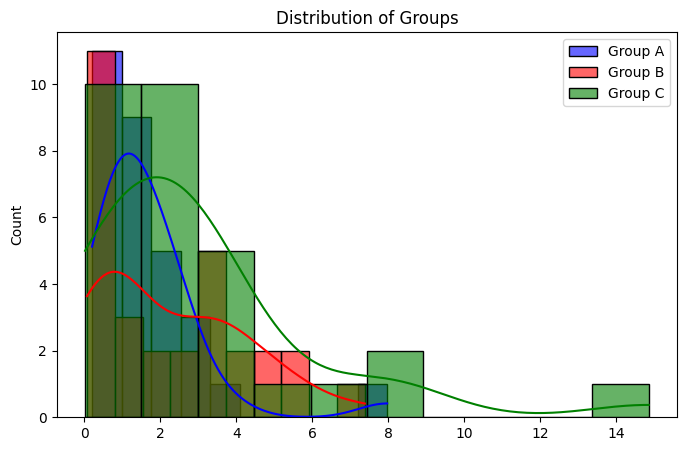

Shapiro-Wilk test p-values:
Group A: 2.7939247897352526e-06
Group B: 0.008591666379322268
Group C: 2.10442965282592e-05
Levene’s test p-value: 0.05490060052030041

ANOVA Results:
              sum_sq    df         F    PR(>F)
Group      26.987947   2.0  2.533211  0.085248
Residual  463.433872  87.0       NaN       NaN
No significant difference found, but assumptions should still be checked.

Kruskal-Wallis test p-value: 0.2208910975715463


C:\Users\sarum\AppData\Local\Temp\ipykernel_4972\1244296288.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
import pandas as pd
import statsmodels.api as sm
group1 = np.random.exponential(scale=2, size=30)
group2 = np.random.exponential(scale=2, size=30)
group3 = np.random.exponential(scale=2, size=30)

data = {'Group': ['A']*30 + ['B']*30 + ['C']*30,
        'Values': np.concatenate([group1, group2, group3])}
df = pd.DataFrame(data)
plt.figure(figsize=(8, 5))
sns.histplot(group1, kde=True, label='Group A', bins=10, color='blue', alpha=0.6)
sns.histplot(group2, kde=True, label='Group B', bins=10, color='red', alpha=0.6)
sns.histplot(group3, kde=True, label='Group C', bins=10, color='green', alpha=0.6)
plt.legend()
plt.title("Distribution of Groups")
plt.show()
print("Shapiro-Wilk test p-values:")
print("Group A:", stats.shapiro(group1).pvalue)
print("Group B:", stats.shapiro(group2).pvalue)
print("Group C:", stats.shapiro(group3).pvalue)
levene_test = stats.levene(group1, group2, group3)
print("Levene’s test p-value:", levene_test.pvalue)
model = ols('Values ~ Group', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA Results:")
print(anova_table)
if anova_table['PR(>F)'][0] < 0.05:
    print("Significant difference found, but ANOVA assumptions might be violated.")
else:
    print("No significant difference found, but assumptions should still be checked.")
kruskal_test = stats.kruskal(group1, group2, group3)
print("\nKruskal-Wallis test p-value:", kruskal_test.pvalue)
